## Expert Notebook: Variational Autoencoder on Fashion-MNIST

In this notebook, we build a **Variational Autoencoder (VAE)** on Fashion-MNIST.

A VAE is different from a normal autoencoder because it learns a **probability-based latent space**.

Instead of encoding an image into one fixed compressed code, the encoder learns:

- **μ (mean):** centre of the latent distribution
- **log variance:** spread of the latent distribution
- **z:** sampled latent point used by the decoder

### Main goals
- Build a VAE encoder that outputs μ and log variance
- Apply the reparameterisation trick: `z = μ + σ × ε`
- Train VAE models with β = 1 and β = 4
- Compare reconstruction quality and latent-space structure
- Generate new Fashion-MNIST-like images from a 2D latent space

In [1]:
# ============================================================
# Learning Day 6: Autoencoders Fundamentals
# Expert Notebook: Variational Autoencoder on Fashion-MNIST
# Step 1: Import libraries and check environment
# ============================================================

# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Check environment
print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

# Check GPU availability
gpus = tf.config.list_physical_devices("GPU")
print("GPU available:", len(gpus) > 0)

if gpus:
    print("GPU device:", gpus[0].name)
else:
    print("Running on CPU")

2026-06-06 19:46:41.446729: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.16.2
NumPy version: 1.26.4
GPU available: False
Running on CPU


### Dataset Overview

The Fashion-MNIST dataset was loaded successfully.

Each image is a **28 × 28 grayscale clothing image**, where every pixel represents brightness intensity from **0 to 255** before preprocessing.

This dataset is suitable for a Variational Autoencoder because it contains different visual categories such as shoes, bags, shirts, coats, and trousers. The VAE will learn to compress these images into a small **2D latent space** and later reconstruct or generate fashion-like images from that space.

In this project, labels are used only for interpretation and visualisation. The VAE itself learns from image reconstruction, not from class labels.

In [2]:
# ============================================================
# Step 2: Load and inspect Fashion-MNIST
# ============================================================

# Load Fashion-MNIST from Keras
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Class names for interpretation only
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

# Print dataset shapes
print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test images shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

# Pixel range before preprocessing
print("\nPixel value range before normalization:")
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

# Show first 10 labels
print("\nFirst 10 training labels:")
for label in y_train[:10]:
    print(label, "→", class_names[label])

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)

Pixel value range before normalization:
Minimum pixel value: 0
Maximum pixel value: 255

First 10 training labels:
9 → Ankle boot
0 → T-shirt/top
0 → T-shirt/top
3 → Dress
0 → T-shirt/top
2 → Pullover
7 → Sneaker
2 → Pullover
5 → Sandal
5 → Sandal


### Dataset Loading — Conclusion

Fashion-MNIST was loaded successfully.

From theory, we know that a VAE needs input data that it can compress into a latent space and reconstruct again.

In this notebook, each Fashion-MNIST image is a **28 × 28 grayscale clothing image**.  
These images will later be compressed by the VAE encoder into a 2D latent representation using **μ**, **log variance**, and sampled **z** values.

## 2. Visual Inspection of Fashion-MNIST Images

Before preprocessing and model building, we inspect sample images from the dataset.

This step helps us understand the visual patterns the VAE will need to learn, such as:

- shoe outlines
- shirt and coat shapes
- trouser structure
- sandal straps
- texture and brightness differences

From the theory side, this connects to the idea of **latent space**.  
The VAE will later try to place visually similar items close together in a compressed hidden space.

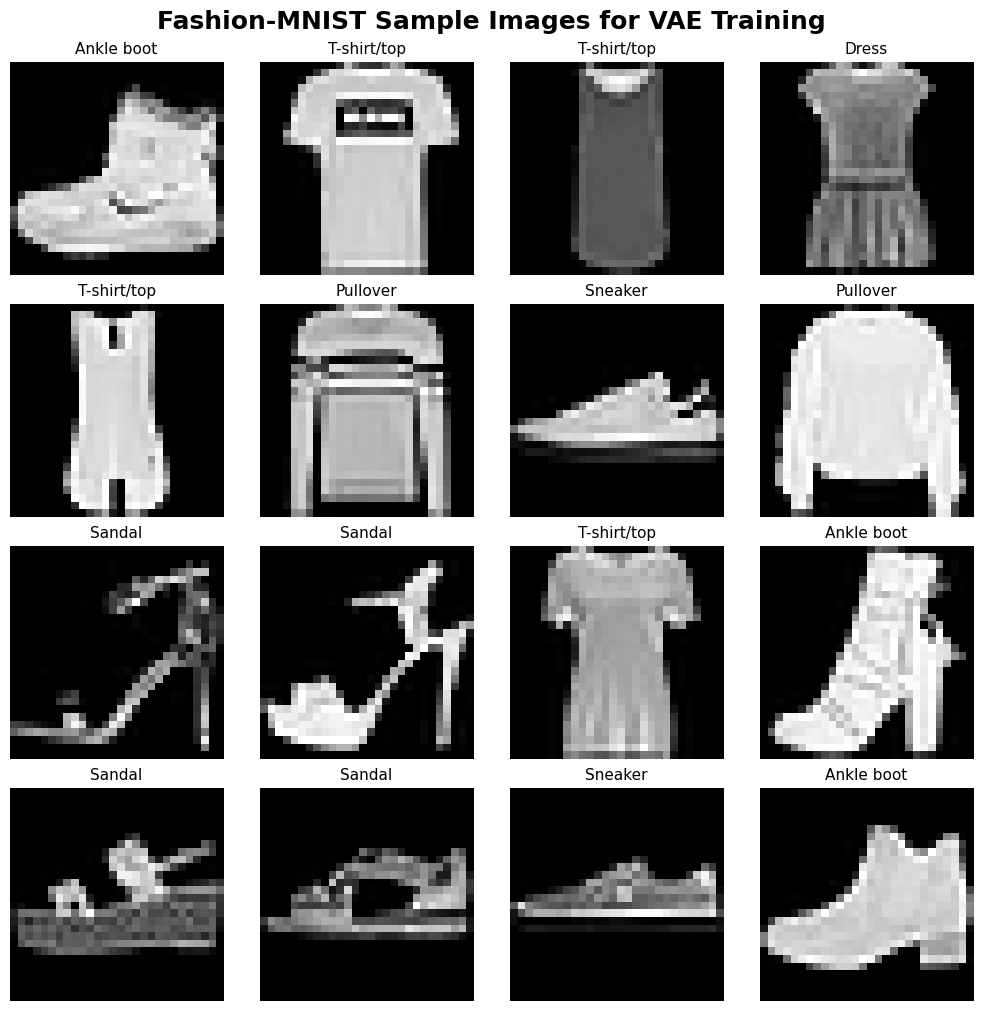

Single image shape: (28, 28)
Single image data type: uint8
Pixel range in first sample image: 0 to 255


In [3]:
# ============================================================
# Step 3: Visualize sample Fashion-MNIST images
# ============================================================

# Number of sample images to display
num_images = 16

# Select sample images and labels
sample_images = x_train[:num_images]
sample_labels = y_train[:num_images]

# Create a clean 4x4 image grid
fig, axes = plt.subplots(
    nrows=4,
    ncols=4,
    figsize=(10, 10),
    constrained_layout=True
)

fig.suptitle(
    "Fashion-MNIST Sample Images for VAE Training",
    fontsize=18,
    fontweight="bold"
)

# Plot each image with class name
for ax, image, label in zip(axes.ravel(), sample_images, sample_labels):
    ax.imshow(image, cmap="gray")
    ax.set_title(class_names[label], fontsize=11)
    ax.axis("off")

plt.show()

# Print one image's technical details
print("Single image shape:", sample_images[0].shape)
print("Single image data type:", sample_images[0].dtype)
print("Pixel range in first sample image:", sample_images[0].min(), "to", sample_images[0].max())

### Visual Inspection — Conclusion

The sample images show that Fashion-MNIST contains different clothing and footwear categories with clear visual structure.

Some classes, such as **ankle boots**, **sneakers**, and **sandals**, have strong shape-based patterns. Other classes, such as **T-shirts**, **pullovers**, **coats**, and **dresses**, share similar upper-body structures and may be harder to separate.

This confirms why a VAE is useful here: it can learn a compressed latent representation of these image patterns and later use that latent space for reconstruction and image generation.

- 28 × 28 image
- → normalise to 0–1
- → flatten to 784 values
- → encoder
- → μ and log variance
- → sampled z
- → decoder
- → reconstructed 784 values
- → reshape back to 28 × 28 for visualisation

## 3. Preprocessing for the Variational Autoencoder

Before building the VAE, the Fashion-MNIST images must be prepared for neural network training.

Each image originally has shape:

`28 × 28`

For this CPU-friendly VAE, each image is flattened into:

`784 values`

This means the image is converted from a 2D pixel grid into one long numerical vector.

The pixel values are also normalised from **0–255** to **0–1**.  
This is important because the VAE decoder will use a **sigmoid output layer**, which also produces values between **0 and 1**.

### Theory connection

From the theory, we learned that a VAE compresses input data into a latent distribution using:

- **μ**: the centre of the latent distribution
- **log variance**: the spread of the latent distribution
- **z**: the sampled latent point used by the decoder

Preprocessing prepares the images so they can move through this VAE pipeline correctly.

In [4]:
# ============================================================
# Step 4: Preprocess Fashion-MNIST images for the VAE
# ============================================================

# Normalize pixel values from 0-255 to 0-1
# This makes training smoother and matches the sigmoid decoder output range

x_train_norm = x_train.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

# Flatten each 28x28 image into 784 values
# Dense VAE input shape: (number_of_images, 784)

x_train_flat = x_train_norm.reshape((x_train_norm.shape[0], 28 * 28))
x_test_flat = x_test_norm.reshape((x_test_norm.shape[0], 28 * 28))

# Keep 2D image format for later visualisation
# These will be used when showing original vs reconstructed images

x_train_images = x_train_norm
x_test_images = x_test_norm

# Print shape changes
print("Original training shape:", x_train.shape)
print("Normalized training shape:", x_train_norm.shape)
print("Flattened training shape:", x_train_flat.shape)

print("\nOriginal test shape:", x_test.shape)
print("Normalized test shape:", x_test_norm.shape)
print("Flattened test shape:", x_test_flat.shape)

# Confirm normalized pixel range
print("\nPixel value range after normalization:")
print("Training min:", x_train_flat.min())
print("Training max:", x_train_flat.max())
print("Test min:", x_test_flat.min())
print("Test max:", x_test_flat.max())

Original training shape: (60000, 28, 28)
Normalized training shape: (60000, 28, 28)
Flattened training shape: (60000, 784)

Original test shape: (10000, 28, 28)
Normalized test shape: (10000, 28, 28)
Flattened test shape: (10000, 784)

Pixel value range after normalization:
Training min: 0.0
Training max: 1.0
Test min: 0.0
Test max: 1.0


### Preprocessing — Conclusion

The Fashion-MNIST images were successfully prepared for the VAE.

Each image was normalised from **0–255** to **0–1**, then flattened from **28 × 28** into **784 input values**.

This preprocessing step connects directly to the VAE architecture:

- the **encoder** will receive 784 input values,
- it will learn **μ** and **log variance**,
- the sampling layer will create a latent point **z**,
- and the decoder will reconstruct the image back into 784 output values.

The 2D image format was also kept separately for visual comparison later.

## 4. Create the VAE Sampling Layer

A normal autoencoder sends one fixed bottleneck code to the decoder.

A VAE works differently.

The encoder produces:

- **μ**: the centre of the latent distribution
- **log variance**: the spread of the latent distribution

The sampling layer then creates the actual latent vector **z** using the reparameterisation trick:

`z = μ + σ × ε`

This allows the VAE to include controlled randomness while still learning through backpropagation.

In this notebook, the latent space has **2 dimensions**, so each image will be represented by two latent values.

In [5]:
# ============================================================
# Step 5: Define the VAE sampling layer
# ============================================================

class Sampling(layers.Layer):
    """
    Sampling layer for the Variational Autoencoder.

    The encoder gives:
    - z_mean: centre of the latent distribution
    - z_log_var: log variance / spread of the latent distribution

    This layer samples:
    z = z_mean + sigma * epsilon
    """

    def call(self, inputs):
        # Unpack encoder outputs
        z_mean, z_log_var = inputs

        # Get batch size and latent dimension dynamically
        batch_size = tf.shape(z_mean)[0]
        latent_dim = tf.shape(z_mean)[1]

        # Random noise sampled from a normal distribution
        epsilon = tf.random.normal(shape=(batch_size, latent_dim))

        # Convert log variance to standard deviation
        sigma = tf.exp(0.5 * z_log_var)

        # Reparameterisation trick
        z = z_mean + sigma * epsilon

        return z


print("Sampling layer created successfully.")

Sampling layer created successfully.


### Sampling Layer — Conclusion

The sampling layer implements the key VAE idea: the model does not pass one fixed compressed code directly to the decoder.

Instead, the encoder will produce:

- **μ (`z_mean`)**: the centre of the latent distribution
- **log variance (`z_log_var`)**: the spread of the latent distribution

The sampling layer then creates the actual latent vector:

`z = μ + σ × ε`

This connects the theory of the **reparameterisation trick** to the practical VAE implementation.

## 5. Build the VAE Encoder

The encoder is the first major part of the VAE.

Its job is to compress each Fashion-MNIST image from **784 input values** into a small **2D latent representation**.

Unlike a normal autoencoder, the VAE encoder does not output only one bottleneck vector.

Instead, it outputs:

- **`z_mean`**: the centre of the image in latent space
- **`z_log_var`**: the spread around that centre
- **`z`**: the sampled latent point created by the sampling layer

Because we use a **2D latent space**, each image will be represented using two latent coordinates. This will later allow us to visualise and generate images from the latent space.

In [6]:
# ============================================================
# Step 6: Build the VAE Encoder
# ============================================================

# ------------------------------------------------------------
# 1. Define model dimensions
# ------------------------------------------------------------

input_dim = 784      # One flattened Fashion-MNIST image: 28 × 28 = 784 pixels
hidden_dim = 128     # CPU-friendly hidden layer size
latent_dim = 2       # 2D latent space for visualisation and generation


# ------------------------------------------------------------
# 2. Encoder input
# ------------------------------------------------------------

# Source:
#   This is the first variable in the encoder pipeline.
#   It represents one flattened Fashion-MNIST image.
#
# Flow:
#   original image: 28 × 28
#        ↓ flattening during preprocessing
#   encoder_inputs: (batch_size, 784)

encoder_inputs = keras.Input(
    shape=(input_dim,),
    name="encoder_input"
)


# ------------------------------------------------------------
# 3. Hidden feature layer
# ------------------------------------------------------------

# Source:
#   This layer takes encoder_inputs from the input layer.
#
# Logic:
#   The 784 pixel values are converted into 128 learned image features.
#   These features are later used to create z_mean and z_log_var.
#
# Flow:
#   encoder_inputs: (batch_size, 784)
#        ↓ Dense(128, relu)
#   x: (batch_size, 128)

x = layers.Dense(
    hidden_dim,
    activation="relu",
    name="encoder_dense_128"
)(encoder_inputs)


# ------------------------------------------------------------
# 4. Latent mean: z_mean
# ------------------------------------------------------------

# Source:
#   This layer takes x from the previous Dense layer.
#   x was created from encoder_inputs.
#
# Logic:
#   z_mean tells the VAE the centre position of the image
#   in the 2D latent space.
#
# Flow:
#   x: (batch_size, 128)
#        ↓ Dense(2)
#   z_mean: (batch_size, 2)

z_mean = layers.Dense(
    latent_dim,
    name="z_mean"
)(x)


# ------------------------------------------------------------
# 5. Latent log variance: z_log_var
# ------------------------------------------------------------

# Source:
#   This layer also takes x from the previous Dense layer.
#   x was created from encoder_inputs.
#
# Logic:
#   z_log_var tells the VAE the spread or uncertainty
#   around z_mean.
#
# Flow:
#   x: (batch_size, 128)
#        ↓ Dense(2)
#   z_log_var: (batch_size, 2)

z_log_var = layers.Dense(
    latent_dim,
    name="z_log_var"
)(x)


# ------------------------------------------------------------
# 6. Sample latent vector: z
# ------------------------------------------------------------

# Source:
#   This layer takes z_mean and z_log_var.
#   Both were created from x.
#
# Logic:
#   The Sampling layer applies the reparameterisation trick:
#   z = μ + σ × ε
#
# Flow:
#   z_mean + z_log_var
#        ↓ Sampling layer
#   z: (batch_size, 2)

z = Sampling(name="z_sampling")([z_mean, z_log_var])


# ------------------------------------------------------------
# 7. Create encoder model
# ------------------------------------------------------------

# Complete encoder pipeline:
#   encoder_inputs → x → z_mean / z_log_var → z
#
# Input:
#   encoder_inputs = flattened image
#
# Outputs:
#   z_mean    = latent centre
#   z_log_var = latent spread
#   z         = sampled latent point

encoder = keras.Model(
    inputs=encoder_inputs,
    outputs=[z_mean, z_log_var, z],
    name="vae_encoder"
)


# Display encoder architecture
encoder.summary()

Model: "vae_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_dense_128   │ (None, 128)       │    100,480 │ encoder_input[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        258 │ encoder_dense_12… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        258 │ encoder_dense_12… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_sampling          │ (None, 2)         │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 100,996 (394.52 KB)

 Trainable params: 100,996 (394.52 KB)

 Non-trainable params: 0 (0.00 B)

### VAE Encoder — Conclusion

The VAE encoder was created successfully.

The encoder receives one flattened Fashion-MNIST image with **784 pixel values** and converts it into a hidden representation of **128 learned features**.

From these learned features, the encoder creates two latent outputs:

- **`z_mean`**: the centre position of the image in the 2D latent space
- **`z_log_var`**: the spread or uncertainty around that centre

The sampling layer then combines these two outputs to create **`z`**, the sampled latent point that will be passed into the decoder.

This confirms the key VAE theory in practice: the encoder does not produce one fixed bottleneck code. Instead, it learns a probability-based latent representation.

## 6. Build the VAE Decoder

The decoder is the second major component of the VAE.

The encoder compresses an image into a sampled latent point **`z`** with shape:

`(batch_size, 2)`

The decoder takes this 2D latent point and reconstructs it back into a flattened Fashion-MNIST image with shape:

`(batch_size, 784)`

### Theory connection

From the theory, we learned that the VAE decoder learns how to convert points from latent space back into image space.

This is important because later we can sample new points from the latent space and ask the decoder to generate new Fashion-MNIST-like images.

In [7]:
# ============================================================
# Step 7: Build the VAE Decoder
# ============================================================

# ------------------------------------------------------------
# 1. Decoder input
# ------------------------------------------------------------

# Source:
#   decoder_inputs receives the sampled latent vector z.
#   z comes from the encoder's Sampling layer.
#
# Logic:
#   The decoder starts from a 2D latent point and learns how to
#   reconstruct the original 784-pixel image.
#
# Flow:
#   z: (batch_size, 2)
#        ↓
#   decoder_inputs: (batch_size, 2)

decoder_inputs = keras.Input(
    shape=(latent_dim,),
    name="decoder_input"
)


# ------------------------------------------------------------
# 2. Decoder hidden layer
# ------------------------------------------------------------

# Source:
#   This layer takes decoder_inputs from the decoder input layer.
#
# Logic:
#   The 2D latent point is expanded into 128 learned features.
#   These features help the decoder rebuild the image.
#
# Flow:
#   decoder_inputs: (batch_size, 2)
#        ↓ Dense(128, relu)
#   x: (batch_size, 128)

x = layers.Dense(
    hidden_dim,
    activation="relu",
    name="decoder_dense_128"
)(decoder_inputs)


# ------------------------------------------------------------
# 3. Decoder output layer
# ------------------------------------------------------------

# Source:
#   This layer takes x from the previous decoder Dense layer.
#   x was created from decoder_inputs.
#
# Logic:
#   The decoder reconstructs the image back into 784 pixel values.
#   Sigmoid is used because the original pixels were normalised to 0–1.
#
# Flow:
#   x: (batch_size, 128)
#        ↓ Dense(784, sigmoid)
#   decoder_outputs: (batch_size, 784)

decoder_outputs = layers.Dense(
    input_dim,
    activation="sigmoid",
    name="decoder_output"
)(x)


# ------------------------------------------------------------
# 4. Create decoder model
# ------------------------------------------------------------

# Complete decoder pipeline:
#   decoder_inputs → x → decoder_outputs
#
# Input:
#   decoder_inputs = sampled 2D latent point
#
# Output:
#   decoder_outputs = reconstructed flattened image

decoder = keras.Model(
    inputs=decoder_inputs,
    outputs=decoder_outputs,
    name="vae_decoder"
)


# Display decoder architecture
decoder.summary()

Model: "vae_decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_128 (Dense)       │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Dense)          │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,520 (396.56 KB)

 Trainable params: 101,520 (396.56 KB)

 Non-trainable params: 0 (0.00 B)

### VAE Decoder — Conclusion

The VAE decoder was created successfully.

The decoder receives a sampled latent vector **`z`** with shape **2** and expands it into a reconstructed Fashion-MNIST image with **784 pixel values**.

This connects directly to the generative idea of VAEs:

- the encoder learns where images belong in latent space,
- the sampling layer creates a latent point **`z`**,
- and the decoder learns how to convert that latent point back into an image.

Later, we will sample new points from the 2D latent space and use this decoder to generate new Fashion-MNIST-like images.

## 7. Create the Custom VAE Model

A Variational Autoencoder needs a custom training step because its loss has two parts:

| Loss Component | Purpose |
|---|---|
| **Reconstruction Loss** | Measures how well the decoder rebuilds the input image |
| **KL Divergence** | Keeps the latent space smooth and close to a normal distribution |

The final loss is:

`Total Loss = Reconstruction Loss + β × KL Divergence`

The **β parameter** controls the strength of latent-space regularisation:

- **β = 1** gives the standard VAE balance.
- **β = 4** applies stronger pressure to organise the latent space.

In code, the model flow is:

`x → encoder → z_mean, z_log_var, z → decoder → reconstruction → loss calculation → weight update`

In [8]:
# ============================================================
# Step 8: Define the Custom VAE Model
# ============================================================

class VAE(keras.Model):
    """
    Custom Variational Autoencoder.

    Main VAE flow:
        x → encoder → z_mean, z_log_var, z → decoder → reconstruction

    Main VAE loss:
        total_loss = reconstruction_loss + beta * kl_loss
    """

    def __init__(self, encoder, decoder, beta=1.0, **kwargs):
        """
        __init__ runs automatically when we create a VAE object.

        Example:
            vae_beta_1 = VAE(encoder, decoder, beta=1.0)

        Parameter source:
            encoder → the encoder model we built earlier
            decoder → the decoder model we built earlier
            beta    → controls the strength of KL loss
            self    → the current VAE object
        """
        super().__init__(**kwargs)

        self.encoder = encoder      # stores encoder inside this VAE object
        self.decoder = decoder      # stores decoder inside this VAE object
        self.beta = beta            # stores beta value inside this VAE object

        # These trackers store average losses during each epoch
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        """
        Keras uses this property automatically.

        Logic:
            It tells Keras which metrics should be reset at the start of each epoch.
        """
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]

    def compute_vae_loss(self, x):
        """
        Helper method used by both train_step() and test_step().

        Parameter source:
            x → one batch of flattened Fashion-MNIST images

        Variable flow:
            x → encoder → z_mean, z_log_var, z
            z → decoder → reconstruction
            x + reconstruction → reconstruction_loss
            z_mean + z_log_var → kl_loss
        """

        z_mean, z_log_var, z = self.encoder(x)      # x: (batch, 784) → z values: (batch, 2)
        reconstruction = self.decoder(z)            # z: (batch, 2) → reconstruction: (batch, 784)

        # Reconstruction loss:
        # compares original image x with reconstructed image
        reconstruction_loss = tf.reduce_mean(
            keras.losses.binary_crossentropy(x, reconstruction)
        ) * input_dim

        # KL loss:
        # keeps latent space smooth and close to a normal distribution
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                axis=1
            )
        )

        # Total VAE loss:
        # beta controls how strongly KL loss affects training
        total_loss = reconstruction_loss + self.beta * kl_loss

        return total_loss, reconstruction_loss, kl_loss

    def train_step(self, data):
        """
        train_step() runs automatically during model.fit().

        It performs one training step:
            1. Get one batch of images
            2. Calculate VAE loss
            3. Calculate gradients
            4. Update model weights
            5. Return losses for the training log
        """

        x = data[0] if isinstance(data, tuple) else data   # data comes from model.fit()

        with tf.GradientTape() as tape:
            total_loss, reconstruction_loss, kl_loss = self.compute_vae_loss(x)

        gradients = tape.gradient(total_loss, self.trainable_weights)   # loss → gradients
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))  # gradients → weight updates

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "total_loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result()
        }

    def test_step(self, data):
        """
        test_step() runs automatically during validation.

        Difference from train_step():
            train_step() updates model weights.
            test_step() only calculates validation losses.
        """

        x = data[0] if isinstance(data, tuple) else data   # validation batch from validation_data

        total_loss, reconstruction_loss, kl_loss = self.compute_vae_loss(x)

        # Important:
        # update trackers here so validation losses do not appear as 0.0000
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "total_loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result()
        }


print("Custom VAE class created successfully.")

Custom VAE class created successfully.


### Custom VAE Class — Conclusion

The custom VAE class was created successfully.

This class controls the full VAE training logic:

`x → encoder → z_mean, z_log_var, z → decoder → reconstruction`

It also calculates the two required VAE loss components:

- **Reconstruction loss:** checks how well the image is rebuilt
- **KL loss:** keeps the latent space smooth and organised

The final training objective is:

`total_loss = reconstruction_loss + β × kl_loss`

Next, we create the first VAE model with **β = 1**, which represents the standard VAE balance between reconstruction quality and latent-space organisation.

## 8. Create and Compile the β = 1 VAE

We now create the first VAE model using:

`β = 1`

This is the standard VAE setting.

With **β = 1**, the model tries to balance two goals:

| Goal | Meaning |
|---|---|
| Good reconstruction | Rebuild Fashion-MNIST images clearly |
| Smooth latent space | Keep the 2D latent space organised for generation |

Unlike normal Keras models, we do not pass a separate loss function inside `compile()`, because the custom `train_step()` method already calculates the VAE loss internally.

In [9]:
# ============================================================
# Step 9: Create and compile the beta = 1 VAE
# ============================================================

# Create the first VAE object.
# Source:
#   encoder and decoder were built in previous cells.
#
# Method basics:
#   VAE(...) automatically calls the __init__ method inside the VAE class.
#   The parameters encoder, decoder, and beta are passed into __init__.
#
# Logic:
#   beta = 1 gives the standard balance between reconstruction loss and KL loss.

vae_beta_1 = VAE(
    encoder=encoder,
    decoder=decoder,
    beta=1.0,
    name="vae_beta_1"
)

# Compile the model.
# Important:
#   We only provide the optimizer here.
#   We do NOT provide loss="..." because train_step() calculates the custom VAE loss.

vae_beta_1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001)
)

print("β = 1 VAE created and compiled successfully.")
print("Model name:", vae_beta_1.name)
print("Beta value:", vae_beta_1.beta)

β = 1 VAE created and compiled successfully.
Model name: vae_beta_1
Beta value: 1.0


### β = 1 VAE Setup — Conclusion

The first VAE model was created and compiled successfully.

This model uses **β = 1**, which means the VAE gives normal balanced importance to both parts of the loss:

- **Reconstruction loss:** helps the decoder rebuild the image clearly
- **KL loss:** helps keep the latent space smooth and organised

The model is now ready for training. During training, Keras will automatically call the custom `train_step()` method inside the VAE class.

## 9. Train the β = 1 VAE

We now train the first VAE model.

Because this notebook is running on CPU, we use a smaller training subset to keep runtime manageable.

During training, the model follows this flow:

`x → encoder → z_mean, z_log_var, z → decoder → reconstruction → VAE loss → weight update`

The input and target are both the same image because the VAE learns reconstruction.  
However, the custom `train_step()` method only uses the input image `x` and calculates the VAE loss internally.

In [10]:
# ============================================================
# Step 10: Train the beta = 1 VAE
# ============================================================

# ------------------------------------------------------------
# 1. Create CPU-friendly training subsets
# ------------------------------------------------------------

# Source:
#   x_train_flat and x_test_flat were created during preprocessing.
#   Each row contains one Fashion-MNIST image flattened into 784 values.
#
# Logic:
#   We use smaller subsets because VAE training is heavier than a normal autoencoder.
#   This keeps training practical on an older Mac / CPU.

x_train_vae_fast = x_train_flat[:10000]      # source: training images → 10,000 samples
x_val_vae_fast = x_test_flat[:2000]          # source: test images → 2,000 validation samples

print("VAE training subset shape:", x_train_vae_fast.shape)
print("VAE validation subset shape:", x_val_vae_fast.shape)


# ------------------------------------------------------------
# 2. Train beta = 1 VAE
# ------------------------------------------------------------

# Method basics:
#   .fit() is a Keras method.
#   When .fit() runs, Keras automatically calls train_step() many times.
#
# Data flow:
#   x_train_vae_fast
#        ↓ model.fit()
#   train_step(data)
#        ↓
#   custom VAE loss calculation and weight update
#
# Note:
#   We pass x_train_vae_fast twice to keep the autoencoder structure clear:
#   input image = target image.
#   Inside train_step(), we only use the input batch x.

history_beta_1 = vae_beta_1.fit(
    x_train_vae_fast,
    x_train_vae_fast,
    epochs=5,
    batch_size=128,
    shuffle=True,
    validation_data=(x_val_vae_fast, x_val_vae_fast),
    verbose=1
)

print("β = 1 VAE training completed.")

VAE training subset shape: (10000, 784)
VAE validation subset shape: (2000, 784)
Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - kl_loss: 16.8446 - reconstruction_loss: 396.4306 - total_loss: 413.2752 - val_kl_loss: 13.3306 - val_reconstruction_loss: 335.4477 - val_total_loss: 348.7784
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - kl_loss: 12.0751 - reconstruction_loss: 317.2444 - total_loss: 329.3194 - val_kl_loss: 10.0336 - val_reconstruction_loss: 303.1991 - val_total_loss: 313.2326
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - kl_loss: 9.4238 - reconstruction_loss: 292.0505 - total_loss: 301.4742 - val_kl_loss: 8.4231 - val_reconstruction_loss: 288.9815 - val_total_loss: 297.4046
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - kl_loss: 8.0507 - reconstruction_loss: 284.7538 - total_loss: 292.8045 - val_kl_loss: 7.5880 - val_reconstruction_loss: 284.7863 - val_total_loss: 292.3744
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 7.4909 - reconstruction_lo

training total_loss:      288.9695

validation total_loss:    289.1259

training reconstruction:  281.4785

validation reconstruction:281.8136

training KL loss:         7.4909

validation KL loss:       7.3123

### β = 1 VAE Training — Conclusion

The β = 1 VAE trained successfully for 5 epochs.

The total loss decreased from a high value in the first epoch to a much lower value by the final epoch. This shows that the model learned to reconstruct Fashion-MNIST images better over time.

The validation loss is close to the training loss, which suggests that the model is learning general image patterns rather than simply memorising the training subset.

For β = 1, the model keeps a standard balance between:

- **reconstruction quality**, controlled by reconstruction loss
- **latent-space organisation**, controlled by KL loss

This trained model will now be used to inspect reconstruction quality and later compare against the β = 4 VAE.

## 10. Visualise β = 1 VAE Training Loss

The VAE has three important losses:

| Loss | Meaning |
|---|---|
| **Total Loss** | Final loss used to train the model |
| **Reconstruction Loss** | Measures how well images are rebuilt |
| **KL Loss** | Measures how strongly the latent space is regularised |

In this section, we plot these losses to understand how the β = 1 VAE learned over time.

Available history columns:
['kl_loss', 'reconstruction_loss', 'total_loss', 'val_kl_loss', 'val_reconstruction_loss', 'val_total_loss', 'epoch']


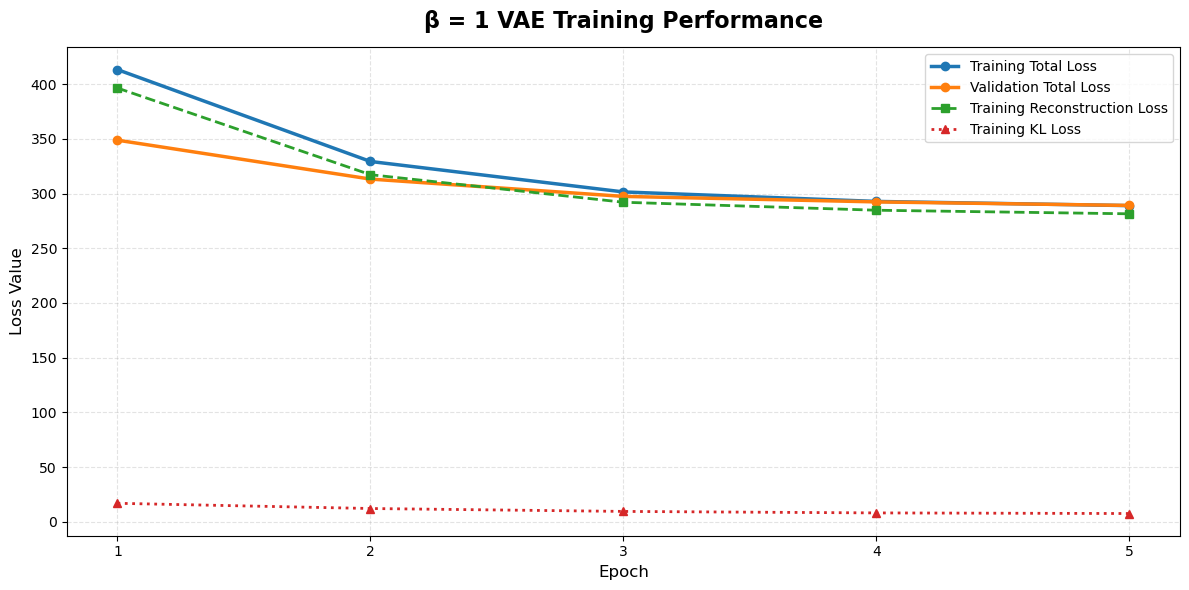

Final β = 1 results:
Training total loss: 288.9695
Validation total loss: 289.1259
Training reconstruction loss: 281.4785
Training KL loss: 7.4909


In [11]:
# ============================================================
# Step 11: Plot beta = 1 VAE training losses
# ============================================================

# Convert the Keras History object into a DataFrame.
# Source: history_beta_1 comes from vae_beta_1.fit(...)
# Logic: a DataFrame makes it easier to inspect and plot each loss.
history_beta_1_df = pd.DataFrame(history_beta_1.history)
history_beta_1_df["epoch"] = range(1, len(history_beta_1_df) + 1)

# Display available loss columns so we can confirm what Keras recorded.
print("Available history columns:")
print(history_beta_1_df.columns.tolist())

# Create a clean plot for total loss, reconstruction loss, and KL loss.
plt.figure(figsize=(12, 6))

plt.plot(
    history_beta_1_df["epoch"],
    history_beta_1_df["total_loss"],
    marker="o",
    linewidth=2.5,
    label="Training Total Loss"
)

plt.plot(
    history_beta_1_df["epoch"],
    history_beta_1_df["val_total_loss"],
    marker="o",
    linewidth=2.5,
    label="Validation Total Loss"
)

plt.plot(
    history_beta_1_df["epoch"],
    history_beta_1_df["reconstruction_loss"],
    marker="s",
    linewidth=2,
    linestyle="--",
    label="Training Reconstruction Loss"
)

plt.plot(
    history_beta_1_df["epoch"],
    history_beta_1_df["kl_loss"],
    marker="^",
    linewidth=2,
    linestyle=":",
    label="Training KL Loss"
)

plt.title(
    "β = 1 VAE Training Performance",
    fontsize=16,
    fontweight="bold",
    pad=14
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss Value", fontsize=12)
plt.xticks(history_beta_1_df["epoch"])
plt.grid(True, linestyle="--", alpha=0.35)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Print final values for interpretation.
print("Final β = 1 results:")
print("Training total loss:", round(history_beta_1_df["total_loss"].iloc[-1], 4))
print("Validation total loss:", round(history_beta_1_df["val_total_loss"].iloc[-1], 4))
print("Training reconstruction loss:", round(history_beta_1_df["reconstruction_loss"].iloc[-1], 4))
print("Training KL loss:", round(history_beta_1_df["kl_loss"].iloc[-1], 4))

### β = 1 Loss Curve — Conclusion

The β = 1 VAE trained successfully.

The total loss and reconstruction loss decreased clearly across the 5 epochs, showing that the model learned to reconstruct Fashion-MNIST images better over time.

The validation total loss stayed close to the training total loss, which suggests that the model is not strongly overfitting.

The KL loss is much smaller than the reconstruction loss because the reconstruction loss is calculated across all **784 image pixels**, while the KL loss regularises only the **2D latent space**.

This result confirms that the β = 1 model has started learning both parts of the VAE objective:

- reconstructing images,
- keeping the latent space reasonably organised.

## 11. Generate Reconstructions with the β = 1 VAE

After training, we use the β = 1 VAE to reconstruct unseen Fashion-MNIST test images.

For stable reconstruction, we use **`z_mean`** instead of the randomly sampled **`z`**.

### Why use `z_mean`?

From VAE theory, the encoder creates a latent distribution.  
The sampled `z` includes randomness, while `z_mean` represents the centre of the distribution.

Using `z_mean` gives a more stable view of what the decoder learned to reconstruct.

In [12]:
# ============================================================
# Step 12: Generate reconstructions using the beta = 1 VAE
# ============================================================

# Use a small unseen test subset for fast evaluation
# Source: x_test_flat comes from preprocessing and contains flattened test images
x_recon_subset = x_test_flat[:1000]                     # shape: (1000, 784)
y_recon_subset = y_test[:1000]                          # labels used only for plot titles

# Encoder step:
# Source: x_recon_subset = original test images
# Logic: encoder places each image into the 2D latent space
# Flow: x_recon_subset → encoder → z_mean, z_log_var, z
z_mean_beta_1, z_log_var_beta_1, z_sample_beta_1 = encoder.predict(
    x_recon_subset,
    batch_size=128,
    verbose=1
)

# Decoder step:
# Source: z_mean_beta_1 comes from the encoder
# Logic: use the centre of the latent distribution for stable reconstruction
# Flow: z_mean_beta_1 → decoder → reconstructed flattened images
reconstructed_beta_1_flat = decoder.predict(
    z_mean_beta_1,
    batch_size=128,
    verbose=1
)

# Reshape flattened images back to 28 × 28 for visualisation
original_beta_1_images = x_recon_subset.reshape((-1, 28, 28))
reconstructed_beta_1_images = reconstructed_beta_1_flat.reshape((-1, 28, 28))

# Calculate MSE reconstruction error per image
# Logic: lower MSE means reconstructed image is closer to original image
reconstruction_errors_beta_1 = np.mean(
    np.square(original_beta_1_images - reconstructed_beta_1_images),
    axis=(1, 2)
)

print("Original image shape:", original_beta_1_images.shape)
print("Reconstructed image shape:", reconstructed_beta_1_images.shape)
print("\nAverage β = 1 reconstruction MSE:", round(reconstruction_errors_beta_1.mean(), 6))
print("Minimum β = 1 reconstruction MSE:", round(reconstruction_errors_beta_1.min(), 6))
print("Maximum β = 1 reconstruction MSE:", round(reconstruction_errors_beta_1.max(), 6))

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Original image shape: (1000, 28, 28)
Reconstructed image shape: (1000, 28, 28)

Average β = 1 reconstruction MSE: 0.039027
Minimum β = 1 reconstruction MSE: 0.007603
Maximum β = 1 reconstruction MSE: 0.136484


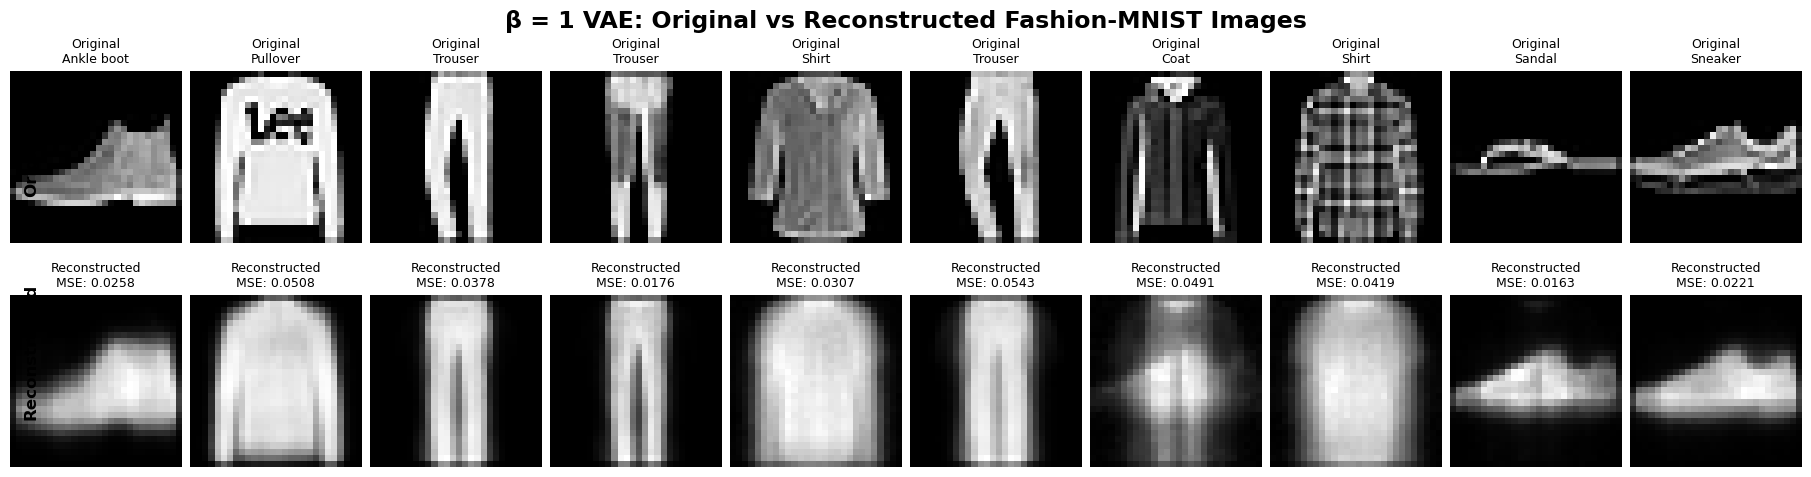

In [13]:
# ============================================================
# Step 13: Visualize beta = 1 VAE reconstructions
# ============================================================

num_images = 10

# Source:
# original_beta_1_images and reconstructed_beta_1_images were created in the previous cell.
# Logic:
# We compare original test images with their VAE reconstructions.
original_samples = original_beta_1_images[:num_images]
reconstructed_samples = reconstructed_beta_1_images[:num_images]
sample_errors = reconstruction_errors_beta_1[:num_images]
sample_labels = y_recon_subset[:num_images]

fig, axes = plt.subplots(
    nrows=2,
    ncols=num_images,
    figsize=(18, 4.8),
    constrained_layout=True
)

fig.suptitle(
    "β = 1 VAE: Original vs Reconstructed Fashion-MNIST Images",
    fontsize=17,
    fontweight="bold"
)

# Row 1:
# Source: original_samples
# Logic: show real unseen Fashion-MNIST test images
for i in range(num_images):
    axes[0, i].imshow(original_samples[i], cmap="gray")
    axes[0, i].set_title(f"Original\n{class_names[sample_labels[i]]}", fontsize=9)
    axes[0, i].axis("off")

# Row 2:
# Source: reconstructed_samples
# Logic: show decoder output created from z_mean latent coordinates
for i in range(num_images):
    axes[1, i].imshow(reconstructed_samples[i], cmap="gray")
    axes[1, i].set_title(f"Reconstructed\nMSE: {sample_errors[i]:.4f}", fontsize=9)
    axes[1, i].axis("off")

# Clean row labels
fig.text(0.01, 0.68, "Original", fontsize=12, fontweight="bold", rotation=90, va="center")
fig.text(0.01, 0.28, "Reconstructed", fontsize=12, fontweight="bold", rotation=90, va="center")

plt.show()

### β = 1 Reconstruction — Conclusion

The β = 1 VAE successfully reconstructed unseen Fashion-MNIST test images.

The reconstructions preserve the general object category, 
such as shoes, trousers, shirts, and coats. However, 
the reconstructed images are noticeably blurrier than the original images.

This happens because the VAE compresses each image into only a **2D latent space**. 

That small latent space is useful for visualisation and image generation, 
but it cannot store all fine image details.

The β = 1 model therefore shows the typical VAE trade-off:

- it learns a smooth latent representation,
- it can reconstruct the main image structure,
- but it loses sharp details and texture.

## 12. Prepare a Fresh β = 4 VAE

To compare β = 1 and β = 4 properly, the β = 4 model must start from a fresh encoder and decoder.

If we reuse the already-trained β = 1 encoder and decoder, the β = 4 model would continue learning from β = 1 weights. That would not be a clean comparison.

In this section, we:

1. save the trained β = 1 encoder and decoder,
2. create a reusable function for building fresh VAE components,
3. build a new encoder and decoder for β = 4.

In [14]:
# ============================================================
# Step 14: Save beta = 1 models and prepare fresh VAE components
# ============================================================

# Save trained beta = 1 components before creating beta = 4 components
encoder_beta_1 = encoder          # trained encoder from beta = 1 VAE
decoder_beta_1 = decoder          # trained decoder from beta = 1 VAE


def build_vae_components(input_dim=784, hidden_dim=128, latent_dim=2, model_suffix=""):
    """
    Build a fresh encoder and decoder with the same VAE architecture.

    Method basics:
        This is a normal helper function, not a class method.
        We call it manually when we need new encoder/decoder models.

    Purpose:
        Create fresh models so beta = 4 starts from new weights.
    """

    # Encoder input: flattened image batch
    encoder_inputs = keras.Input(
        shape=(input_dim,),
        name=f"encoder_input{model_suffix}"
    )

    # Flow: encoder_inputs → Dense(128) → x
    x = layers.Dense(
        hidden_dim,
        activation="relu",
        name=f"encoder_dense_128{model_suffix}"
    )(encoder_inputs)

    # Flow: x → z_mean and z_log_var
    z_mean = layers.Dense(
        latent_dim,
        name=f"z_mean{model_suffix}"
    )(x)

    z_log_var = layers.Dense(
        latent_dim,
        name=f"z_log_var{model_suffix}"
    )(x)

    # Flow: z_mean + z_log_var → Sampling → z
    z = Sampling(name=f"z_sampling{model_suffix}")([z_mean, z_log_var])

    fresh_encoder = keras.Model(
        inputs=encoder_inputs,
        outputs=[z_mean, z_log_var, z],
        name=f"vae_encoder{model_suffix}"
    )

    # Decoder input: sampled 2D latent point
    
    decoder_inputs = keras.Input(
        shape=(latent_dim,),
        name=f"decoder_input{model_suffix}"
    )

    # Flow: decoder_inputs → Dense(128) → decoder hidden features
    
    x = layers.Dense(
        hidden_dim,
        activation="relu",
        name=f"decoder_dense_128{model_suffix}"
    )(decoder_inputs)

    # Flow: hidden features → Dense(784, sigmoid) → reconstructed image
    
    decoder_outputs = layers.Dense(
        input_dim,
        activation="sigmoid",
        name=f"decoder_output{model_suffix}"
    )(x)

    fresh_decoder = keras.Model(
        inputs=decoder_inputs,
        outputs=decoder_outputs,
        name=f"vae_decoder{model_suffix}"
    )

    return fresh_encoder, fresh_decoder


# Create fresh beta = 4 encoder and decoder
encoder_beta_4, decoder_beta_4 = build_vae_components(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    latent_dim=latent_dim,
    model_suffix="_beta_4"
)

print("β = 1 trained encoder and decoder saved.")
print("Fresh β = 4 encoder and decoder created.")
print("β = 4 encoder name:", encoder_beta_4.name)
print("β = 4 decoder name:", decoder_beta_4.name)

β = 1 trained encoder and decoder saved.
Fresh β = 4 encoder and decoder created.
β = 4 encoder name: vae_encoder_beta_4
β = 4 decoder name: vae_decoder_beta_4


## 13. Create and Compile the β = 4 VAE

We now create the second VAE model using:

`β = 4`

The model architecture is the same as the β = 1 VAE, but the loss function gives more importance to KL divergence.

### Theory connection

In a VAE, the total loss is:

`total_loss = reconstruction_loss + β × kl_loss`

When **β = 4**, the model is pushed harder to organise the latent space.

This usually means:

- the latent space may become smoother and more structured,
- but reconstructions may become blurrier,
- because the model is forced to care more about latent-space regularisation.

In [16]:
# ============================================================
# Step 15: Create and compile the beta = 4 VAE
# ============================================================

# Create a new VAE object using the fresh beta = 4 encoder and decoder.
# Method basics:
#   VAE(...) calls the __init__ method inside the VAE class.
#   encoder_beta_4 and decoder_beta_4 come from build_vae_components().
# Logic:
#   beta = 4 gives stronger importance to KL loss.

vae_beta_4 = VAE(
    encoder=encoder_beta_4,
    decoder=decoder_beta_4,
    beta=4.0,
    name="vae_beta_4"
)

# Compile the beta = 4 model.
# We only provide the optimizer because custom train_step() calculates the VAE loss.
vae_beta_4.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001)
)

print("β = 4 VAE created and compiled successfully.")
print("Model name:", vae_beta_4.name)
print("Beta value:", vae_beta_4.beta)

β = 4 VAE created and compiled successfully.
Model name: vae_beta_4
Beta value: 4.0


## 14. Train the β = 4 VAE

We now train the second VAE model using **β = 4**.

The architecture is the same as the β = 1 model, but the loss behaves differently:

`total_loss = reconstruction_loss + 4 × kl_loss`

### Theory connection

A higher β value gives more importance to **KL divergence**.

This means the model is pushed harder to organise the latent space.  
However, this can also reduce reconstruction quality because the model is not allowed to freely store every image detail.

In this section, we train β = 4 on the same CPU-friendly data subset used for β = 1.

In [17]:
# ============================================================
# Step 16: Train the beta = 4 VAE
# ============================================================

# Source:
#   x_train_vae_fast and x_val_vae_fast were already created for beta = 1 training.
# Logic:
#   We reuse the same data subsets so beta = 1 and beta = 4 are compared fairly.

print("VAE training subset shape:", x_train_vae_fast.shape)
print("VAE validation subset shape:", x_val_vae_fast.shape)

# Method basics:
#   .fit() is called manually here.
#   During .fit(), Keras automatically calls train_step() from our custom VAE class.
#
# Flow:
#   x_train_vae_fast
#        ↓ model.fit()
#   train_step(data)
#        ↓
#   encoder → decoder → VAE loss → weight update

history_beta_4 = vae_beta_4.fit(
    x_train_vae_fast,                         # input images: (10000, 784)
    x_train_vae_fast,                         # target images: same as input for reconstruction
    epochs=5,                                 # CPU-friendly training
    batch_size=128,                           # manageable batch size for older Mac
    shuffle=True,
    validation_data=(x_val_vae_fast, x_val_vae_fast),
    verbose=1
)

print("β = 4 VAE training completed.")

VAE training subset shape: (10000, 784)
VAE validation subset shape: (2000, 784)
Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - kl_loss: 4.6533 - reconstruction_loss: 419.8230 - total_loss: 438.4361 - val_kl_loss: 4.5371 - val_reconstruction_loss: 348.5822 - val_total_loss: 366.7308
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 4.3208 - reconstruction_loss: 333.3206 - total_loss: 350.6039 - val_kl_loss: 4.3461 - val_reconstruction_loss: 321.5180 - val_total_loss: 338.9025
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 3.9187 - reconstruction_loss: 314.3421 - total_loss: 330.0167 - val_kl_loss: 3.8734 - val_reconstruction_loss: 309.1862 - val_total_loss: 324.6795
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 3.8955 - reconstruction_loss: 303.0401 - total_loss: 318.6221 - val_kl_loss: 3.9232 - val_reconstruction_loss: 299.8748 - val_total_loss: 315.5675
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 3.8940 - reconstruction_loss: 

### β = 4 VAE Training — Conclusion

The β = 4 VAE trained successfully for 5 epochs.

The total loss, reconstruction loss, and KL loss decreased across training, showing that the model learned the VAE objective.

Compared with β = 1, the β = 4 model gives stronger importance to KL divergence:

`total_loss = reconstruction_loss + 4 × kl_loss`

This stronger regularisation leads to a lower KL loss, meaning the latent space is pushed closer to a smooth normal distribution.

However, the reconstruction loss is higher than β = 1, which suggests that the β = 4 model may produce blurrier reconstructions.

This confirms the expected β-VAE trade-off:

- **β = 1:** better reconstruction quality
- **β = 4:** stronger latent-space organisation

Available history columns:
['kl_loss', 'reconstruction_loss', 'total_loss', 'val_kl_loss', 'val_reconstruction_loss', 'val_total_loss', 'epoch']


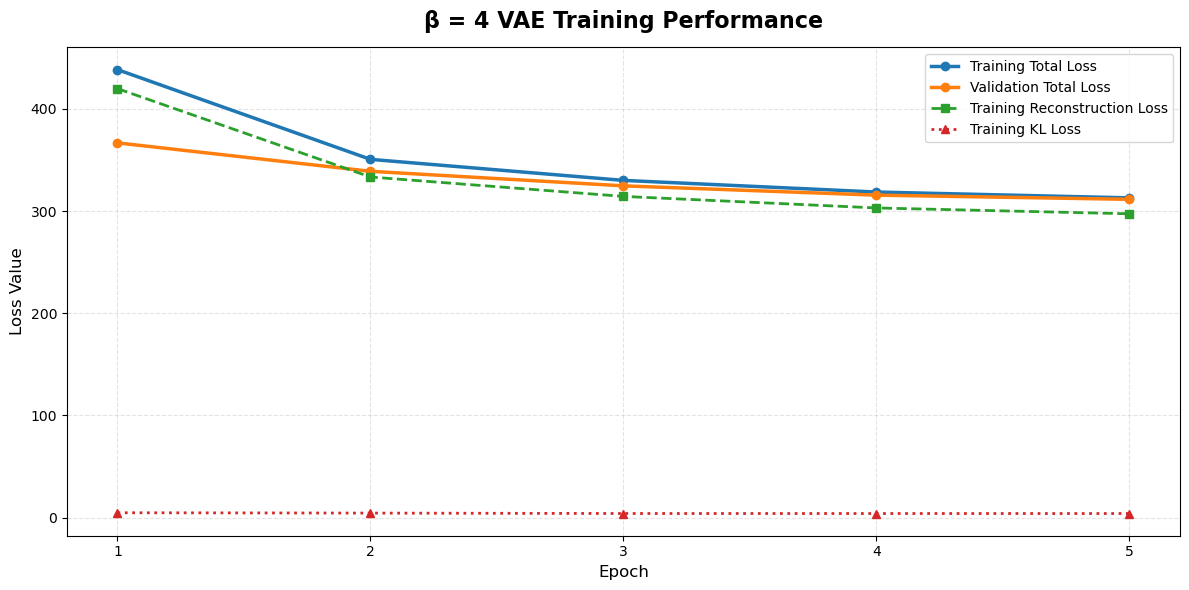

Final β = 4 results:
Training total loss: 312.8964
Validation total loss: 311.4822
Training reconstruction loss: 297.3202
Training KL loss: 3.894


In [18]:
# ============================================================
# Step 17: Plot beta = 4 VAE training losses
# ============================================================

# Source:
#   history_beta_4 comes from vae_beta_4.fit(...)
# Logic:
#   Convert training history into a DataFrame so each loss can be plotted clearly.
history_beta_4_df = pd.DataFrame(history_beta_4.history)
history_beta_4_df["epoch"] = range(1, len(history_beta_4_df) + 1)

print("Available history columns:")
print(history_beta_4_df.columns.tolist())

# Plot total loss, validation total loss, reconstruction loss, and KL loss
plt.figure(figsize=(12, 6))

plt.plot(
    history_beta_4_df["epoch"],
    history_beta_4_df["total_loss"],
    marker="o",
    linewidth=2.5,
    label="Training Total Loss"
)

plt.plot(
    history_beta_4_df["epoch"],
    history_beta_4_df["val_total_loss"],
    marker="o",
    linewidth=2.5,
    label="Validation Total Loss"
)

plt.plot(
    history_beta_4_df["epoch"],
    history_beta_4_df["reconstruction_loss"],
    marker="s",
    linewidth=2,
    linestyle="--",
    label="Training Reconstruction Loss"
)

plt.plot(
    history_beta_4_df["epoch"],
    history_beta_4_df["kl_loss"],
    marker="^",
    linewidth=2,
    linestyle=":",
    label="Training KL Loss"
)

plt.title(
    "β = 4 VAE Training Performance",
    fontsize=16,
    fontweight="bold",
    pad=14
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss Value", fontsize=12)
plt.xticks(history_beta_4_df["epoch"])
plt.grid(True, linestyle="--", alpha=0.35)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("Final β = 4 results:")
print("Training total loss:", round(history_beta_4_df["total_loss"].iloc[-1], 4))
print("Validation total loss:", round(history_beta_4_df["val_total_loss"].iloc[-1], 4))
print("Training reconstruction loss:", round(history_beta_4_df["reconstruction_loss"].iloc[-1], 4))
print("Training KL loss:", round(history_beta_4_df["kl_loss"].iloc[-1], 4))

### β = 4 Loss Curve — Conclusion

The β = 4 VAE trained successfully.

The total loss and reconstruction loss decreased across the 5 epochs, showing that the model learned to reconstruct Fashion-MNIST images better over time.

The validation total loss stayed close to the training total loss, which suggests that the model is not strongly overfitting.

Compared with β = 1, the β = 4 model has a higher reconstruction loss but a lower KL loss. This matches the expected β-VAE behaviour:

- stronger latent-space regularisation,
- smoother latent structure,
- but weaker reconstruction detail.

## 15. Generate Reconstructions with the β = 4 VAE

After training the β = 4 model, we reconstruct unseen Fashion-MNIST test images.

As with β = 1, we use **`z_mean`** for stable reconstruction.

### Theory connection

The β = 4 model gives stronger importance to KL divergence.  
This should make the latent space more organised, but it may also make reconstructed images blurrier because the model is less free to store image-specific details.

In [19]:
# ============================================================
# Step 18: Generate reconstructions using the beta = 4 VAE
# ============================================================

# Use the same unseen test subset used for beta = 1 reconstruction.
# This keeps beta = 1 and beta = 4 comparison fair.
x_recon_subset = x_test_flat[:1000]          # source: flattened test images, shape (1000, 784)
y_recon_subset = y_test[:1000]               # labels used only for plot titles

# Encoder step:
# Flow: original test images → beta 4 encoder → z_mean, z_log_var, sampled z
z_mean_beta_4, z_log_var_beta_4, z_sample_beta_4 = encoder_beta_4.predict(
    x_recon_subset,
    batch_size=128,
    verbose=1
)

# Decoder step:
# Flow: z_mean_beta_4 → beta 4 decoder → reconstructed flattened images
# Logic: z_mean gives stable reconstruction without random sampling noise.
reconstructed_beta_4_flat = decoder_beta_4.predict(
    z_mean_beta_4,
    batch_size=128,
    verbose=1
)

# Reshape flattened outputs back into image format for visualisation.
original_beta_4_images = x_recon_subset.reshape((-1, 28, 28))
reconstructed_beta_4_images = reconstructed_beta_4_flat.reshape((-1, 28, 28))

# Calculate reconstruction error per image.
# Lower MSE means the reconstructed image is closer to the original image.
reconstruction_errors_beta_4 = np.mean(
    np.square(original_beta_4_images - reconstructed_beta_4_images),
    axis=(1, 2)
)

print("Original image shape:", original_beta_4_images.shape)
print("Reconstructed image shape:", reconstructed_beta_4_images.shape)

print("\nAverage β = 4 reconstruction MSE:", round(reconstruction_errors_beta_4.mean(), 6))
print("Minimum β = 4 reconstruction MSE:", round(reconstruction_errors_beta_4.min(), 6))
print("Maximum β = 4 reconstruction MSE:", round(reconstruction_errors_beta_4.max(), 6))

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Original image shape: (1000, 28, 28)
Reconstructed image shape: (1000, 28, 28)

Average β = 4 reconstruction MSE: 0.044348
Minimum β = 4 reconstruction MSE: 0.010796
Maximum β = 4 reconstruction MSE: 0.167717


### β = 4 Reconstruction Output — Initial Interpretation

The β = 4 VAE successfully reconstructed unseen Fashion-MNIST test images.

The average reconstruction MSE is **0.044348**, which is higher than the β = 1 reconstruction MSE of **0.039027**.

This means the β = 4 model produced slightly weaker reconstructions.

This result matches the expected β-VAE trade-off:

- **β = 1** gives better reconstruction quality.
- **β = 4** gives stronger latent-space regularisation, but may lose more image detail.

The next step is to visually inspect the β = 4 reconstructions.

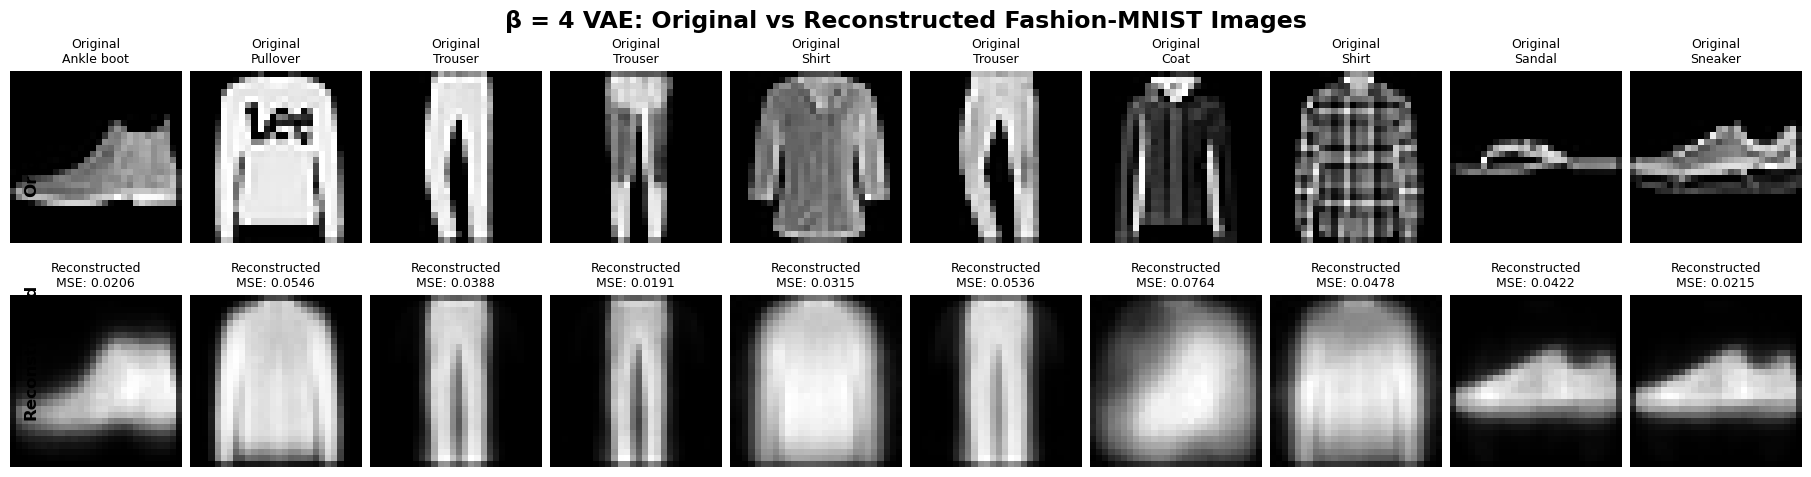

In [20]:
# ============================================================
# Step 19: Visualize beta = 4 VAE reconstructions
# ============================================================

num_images = 10

# Source:
#   These variables were created in the previous reconstruction cell.
# Logic:
#   We compare original test images with beta = 4 reconstructed images.
original_samples = original_beta_4_images[:num_images]
reconstructed_samples = reconstructed_beta_4_images[:num_images]
sample_errors = reconstruction_errors_beta_4[:num_images]
sample_labels = y_recon_subset[:num_images]

fig, axes = plt.subplots(
    nrows=2,
    ncols=num_images,
    figsize=(18, 4.8),
    constrained_layout=True
)

fig.suptitle(
    "β = 4 VAE: Original vs Reconstructed Fashion-MNIST Images",
    fontsize=17,
    fontweight="bold"
)

# Row 1: original unseen test images
for i in range(num_images):
    axes[0, i].imshow(original_samples[i], cmap="gray")
    axes[0, i].set_title(f"Original\n{class_names[sample_labels[i]]}", fontsize=9)
    axes[0, i].axis("off")

# Row 2: beta = 4 reconstructions from z_mean
for i in range(num_images):
    axes[1, i].imshow(reconstructed_samples[i], cmap="gray")
    axes[1, i].set_title(f"Reconstructed\nMSE: {sample_errors[i]:.4f}", fontsize=9)
    axes[1, i].axis("off")

fig.text(0.01, 0.68, "Original", fontsize=12, fontweight="bold", rotation=90, va="center")
fig.text(0.01, 0.28, "Reconstructed", fontsize=12, fontweight="bold", rotation=90, va="center")

plt.show()

### β = 4 Reconstruction — Conclusion

The β = 4 VAE successfully reconstructed unseen Fashion-MNIST test images.

The reconstructions preserve the general object structure, such as shoes, trousers, shirts, and coats. However, the images are slightly blurrier and less detailed than the β = 1 reconstructions.

This matches the expected β-VAE behaviour.

Because β = 4 gives stronger importance to KL divergence, the model focuses more on organising the latent space and less on preserving every image-specific detail.

This confirms the main trade-off:

- **β = 1:** better reconstruction quality
- **β = 4:** stronger latent-space regularisation, but blurrier reconstructions

## 16. Compare β = 1 and β = 4 VAE Results

We now compare the two VAE models directly.

Both models used the same architecture and the same training subset.  
The only difference is the value of **β** in the VAE loss:

`total_loss = reconstruction_loss + β × kl_loss`

This comparison helps us understand how β affects:

- reconstruction quality,
- KL loss,
- total loss,
- and the balance between image detail and latent-space organisation.

In [21]:
# ============================================================
# Step 20: Compare beta = 1 and beta = 4 VAE results
# ============================================================

# Source:
#   history_beta_1_df and history_beta_4_df store training history.
#   reconstruction_errors_beta_1 and reconstruction_errors_beta_4 store test reconstruction MSE.
#
# Logic:
#   We compare final losses and average reconstruction MSE to understand the beta trade-off.

comparison_beta_df = pd.DataFrame({
    "Model": ["VAE β = 1", "VAE β = 4"],
    
    "Final Train Total Loss": [
        history_beta_1_df["total_loss"].iloc[-1],
        history_beta_4_df["total_loss"].iloc[-1]
    ],
    
    "Final Val Total Loss": [
        history_beta_1_df["val_total_loss"].iloc[-1],
        history_beta_4_df["val_total_loss"].iloc[-1]
    ],
    
    "Final Train Reconstruction Loss": [
        history_beta_1_df["reconstruction_loss"].iloc[-1],
        history_beta_4_df["reconstruction_loss"].iloc[-1]
    ],
    
    "Final Train KL Loss": [
        history_beta_1_df["kl_loss"].iloc[-1],
        history_beta_4_df["kl_loss"].iloc[-1]
    ],
    
    "Average Test Reconstruction MSE": [
        reconstruction_errors_beta_1.mean(),
        reconstruction_errors_beta_4.mean()
    ]
})

# Create rounded display version
comparison_beta_df_rounded = comparison_beta_df.copy()

numeric_columns = comparison_beta_df_rounded.columns.drop("Model")
comparison_beta_df_rounded[numeric_columns] = comparison_beta_df_rounded[numeric_columns].round(6)

comparison_beta_df_rounded

,Model,Final Train Total Loss,Final Val Total Loss,Final Train Reconstruction Loss,Final Train KL Loss,Average Test Reconstruction MSE
0,VAE β = 1,288.969452,289.125946,281.478516,7.490874,0.039027
1,VAE β = 4,312.896362,311.482239,297.320160,3.894046,0.044348


### β = 1 vs β = 4 — Interpretation

The comparison table shows the expected β-VAE trade-off.

The **β = 1 VAE** achieved a lower reconstruction loss and lower average test reconstruction MSE. This means it reconstructed Fashion-MNIST images better.

The **β = 4 VAE** achieved a lower KL loss. This means the model pushed the latent space more strongly toward a smooth, regularised normal distribution.

However, this stronger latent-space regularisation came at the cost of reconstruction quality.

In simple terms:

- **β = 1** keeps more image detail.
- **β = 4** creates a more regularised latent space but loses more reconstruction detail.

This confirms the core β-VAE concept: increasing β improves latent-space regularisation but can make reconstructions blurrier.

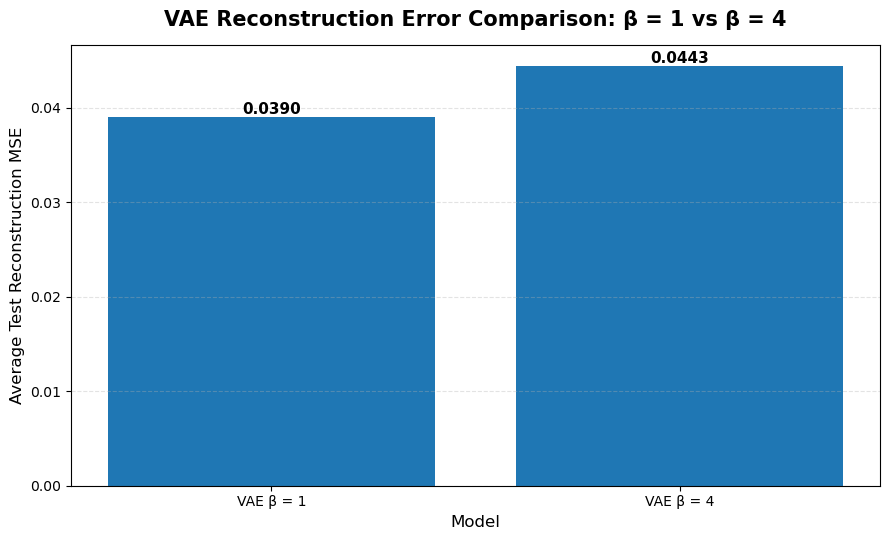

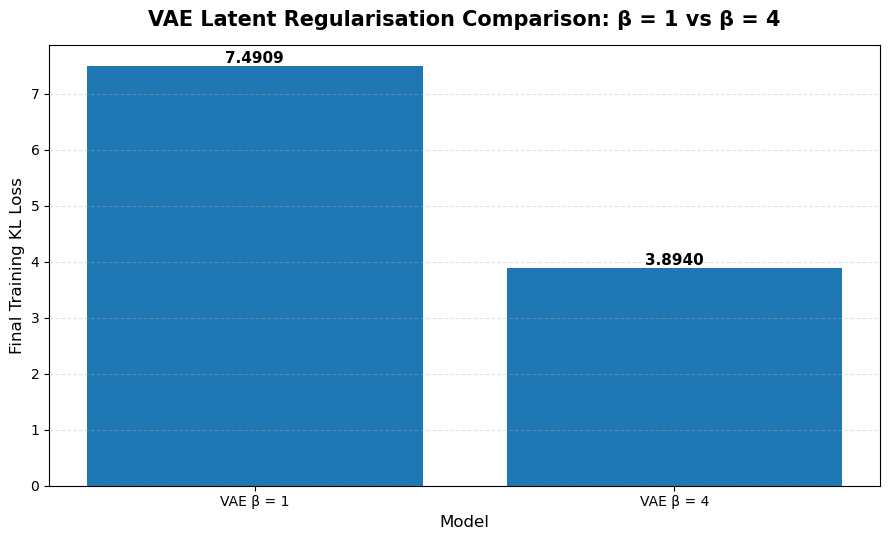

β = 1 average test MSE: 0.039027
β = 4 average test MSE: 0.044348
β = 1 KL loss: 7.490874
β = 4 KL loss: 3.894046


In [22]:
# ============================================================
# Step 21: Visualize beta = 1 vs beta = 4 comparison
# ============================================================

# Source:
#   comparison_beta_df_rounded comes from the beta comparison table.
#
# Logic:
#   We compare reconstruction MSE and KL loss because these show the main beta trade-off:
#   β = 1 → better reconstruction
#   β = 4 → stronger latent-space regularisation

plot_df = comparison_beta_df_rounded.copy()

models = plot_df["Model"]
mse_values = plot_df["Average Test Reconstruction MSE"]
kl_values = plot_df["Final Train KL Loss"]

# -----------------------------
# Chart 1: Reconstruction MSE
# -----------------------------

plt.figure(figsize=(9, 5.5))

bars = plt.bar(
    models,
    mse_values
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.4f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "VAE Reconstruction Error Comparison: β = 1 vs β = 4",
    fontsize=15,
    fontweight="bold",
    pad=14
)

plt.ylabel("Average Test Reconstruction MSE", fontsize=12)
plt.xlabel("Model", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()


# -----------------------------
# Chart 2: KL Loss
# -----------------------------

plt.figure(figsize=(9, 5.5))

bars = plt.bar(
    models,
    kl_values
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.4f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "VAE Latent Regularisation Comparison: β = 1 vs β = 4",
    fontsize=15,
    fontweight="bold",
    pad=14
)

plt.ylabel("Final Training KL Loss", fontsize=12)
plt.xlabel("Model", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()

print("β = 1 average test MSE:", round(mse_values.iloc[0], 6))
print("β = 4 average test MSE:", round(mse_values.iloc[1], 6))
print("β = 1 KL loss:", round(kl_values.iloc[0], 6))
print("β = 4 KL loss:", round(kl_values.iloc[1], 6))

### β Comparison — Conclusion

The β comparison confirms the expected VAE trade-off.

The **β = 1 VAE** achieved a lower average reconstruction MSE:

`0.039027`

This means β = 1 reconstructed Fashion-MNIST images better.

The **β = 4 VAE** achieved a lower KL loss:

`3.894046`

This means β = 4 pushed the latent space more strongly toward a smooth and regularised distribution.

Overall:

- **β = 1** is better for reconstruction quality.
- **β = 4** is better for latent-space regularisation.
- Higher β improves latent structure but can reduce image detail.

## 17. Visualise the 2D Latent Space

The VAE encoder maps each Fashion-MNIST image into a 2D latent space.

For each image, the encoder creates:

- **`z_mean`**: the centre position in latent space
- **`z_log_var`**: the spread around that centre
- **`z`**: a sampled latent point

For visualisation, we use **`z_mean`** because it gives a stable position for each image.

This plot helps us understand whether different fashion classes occupy different areas of the latent space.

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


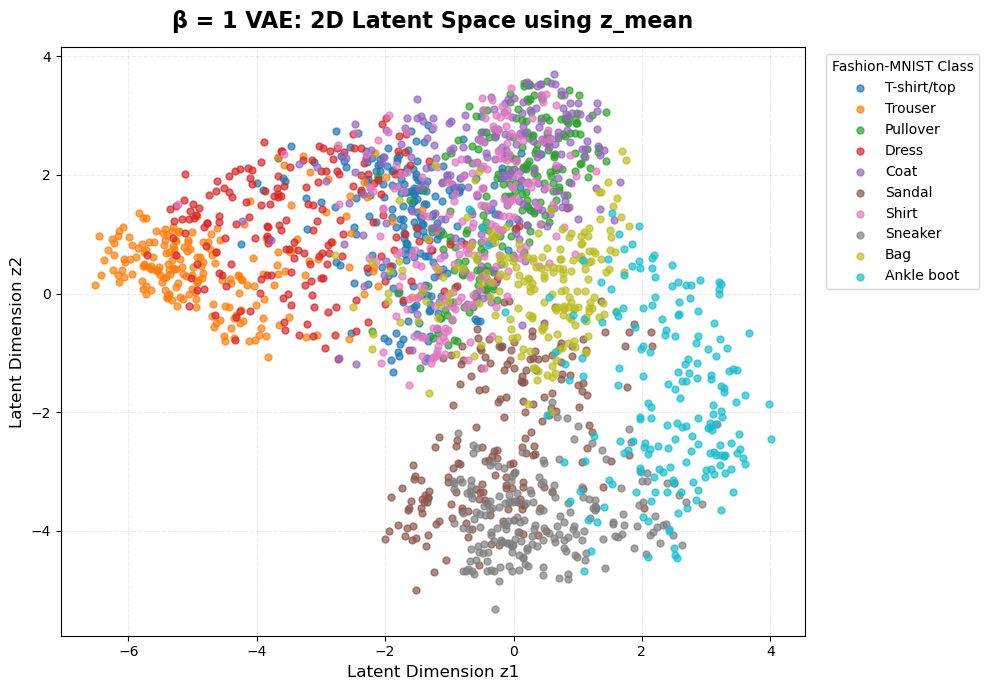

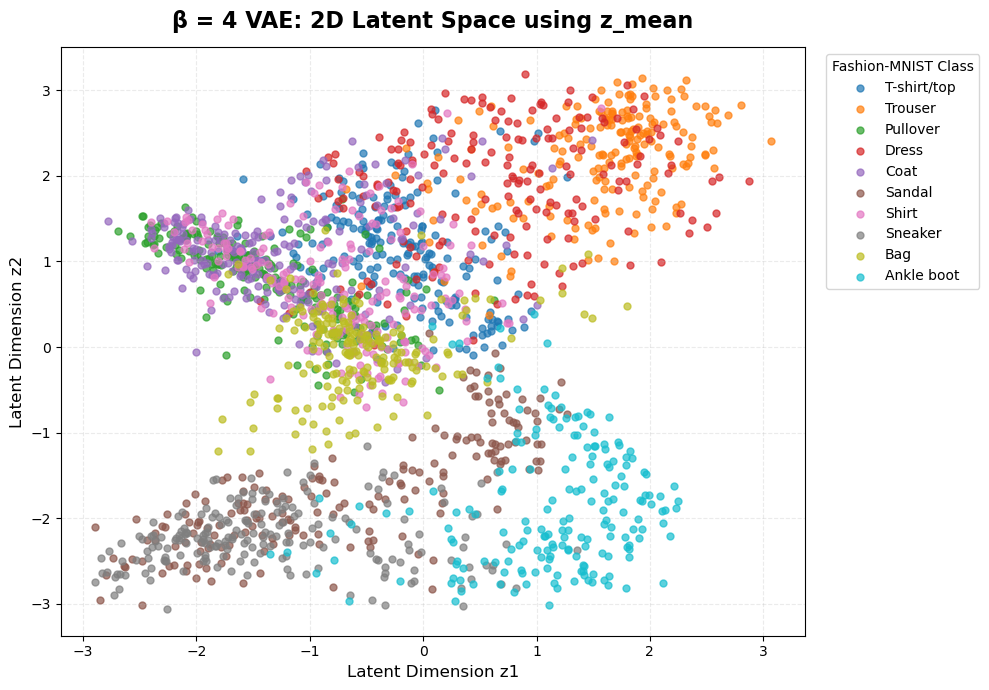

In [23]:
# ============================================================
# Step 22: Visualize beta = 1 and beta = 4 latent spaces
# ============================================================

# Use a small test subset for clear and fast plotting
# Source: x_test_flat = flattened Fashion-MNIST test images
# Logic: labels are used only for coloring, not for training
n_latent_plot = 2000
x_latent_subset = x_test_flat[:n_latent_plot]
y_latent_subset = y_test[:n_latent_plot]

# Flow for beta = 1:
# x_latent_subset → encoder_beta_1 → z_mean_beta_1_plot
z_mean_beta_1_plot, _, _ = encoder_beta_1.predict(
    x_latent_subset,
    batch_size=128,
    verbose=1
)

# Flow for beta = 4:
# x_latent_subset → encoder_beta_4 → z_mean_beta_4_plot
z_mean_beta_4_plot, _, _ = encoder_beta_4.predict(
    x_latent_subset,
    batch_size=128,
    verbose=1
)

# Create DataFrames for cleaner plotting
latent_beta_1_df = pd.DataFrame({
    "z1": z_mean_beta_1_plot[:, 0],
    "z2": z_mean_beta_1_plot[:, 1],
    "label": y_latent_subset,
    "class": [class_names[label] for label in y_latent_subset]
})

latent_beta_4_df = pd.DataFrame({
    "z1": z_mean_beta_4_plot[:, 0],
    "z2": z_mean_beta_4_plot[:, 1],
    "label": y_latent_subset,
    "class": [class_names[label] for label in y_latent_subset]
})

# -----------------------------
# Plot beta = 1 latent space
# -----------------------------

plt.figure(figsize=(10, 7))

for class_id, class_name in enumerate(class_names):
    class_data = latent_beta_1_df[latent_beta_1_df["label"] == class_id]
    plt.scatter(
        class_data["z1"],
        class_data["z2"],
        s=25,
        alpha=0.7,
        label=class_name
    )

plt.title(
    "β = 1 VAE: 2D Latent Space using z_mean",
    fontsize=16,
    fontweight="bold",
    pad=14
)

plt.xlabel("Latent Dimension z1", fontsize=12)
plt.ylabel("Latent Dimension z2", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.25)
plt.legend(title="Fashion-MNIST Class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


# -----------------------------
# Plot beta = 4 latent space
# -----------------------------

plt.figure(figsize=(10, 7))

for class_id, class_name in enumerate(class_names):
    class_data = latent_beta_4_df[latent_beta_4_df["label"] == class_id]
    plt.scatter(
        class_data["z1"],
        class_data["z2"],
        s=25,
        alpha=0.7,
        label=class_name
    )

plt.title(
    "β = 4 VAE: 2D Latent Space using z_mean",
    fontsize=16,
    fontweight="bold",
    pad=14
)

plt.xlabel("Latent Dimension z1", fontsize=12)
plt.ylabel("Latent Dimension z2", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.25)
plt.legend(title="Fashion-MNIST Class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Latent Space Comparison — Conclusion

The β = 1 and β = 4 latent-space plots show different behaviour.

The **β = 1 VAE** creates a wider latent space and preserves more reconstruction detail. This matches its lower reconstruction MSE.

The **β = 4 VAE** creates a more regularised latent space. The points are more compact and pushed into a smoother structure. This matches its lower KL loss.

This confirms the expected β-VAE trade-off:

- **β = 1:** better reconstruction quality, more flexible latent space
- **β = 4:** stronger latent-space organisation, but blurrier reconstructions

Some classes, such as trousers and footwear, form more visible regions. Upper-body clothing classes overlap more because their shapes are visually similar.

## 18. Generate Images from the 2D Latent Space

A key goal of a VAE is generation.

After training, we can choose points from the 2D latent space and pass them into the decoder.

The decoder then converts each latent point into a Fashion-MNIST-like image.

In this section, we sample a grid of points from:

`[-3, 3] × [-3, 3]`

Each point has two coordinates:

`[z1, z2]`

These coordinates are passed into the decoder to generate new images.

### Theory connection

From VAE theory, the latent space is designed to be smooth.  
This means nearby points should generate visually similar images, while faraway points may generate different fashion-like structures.

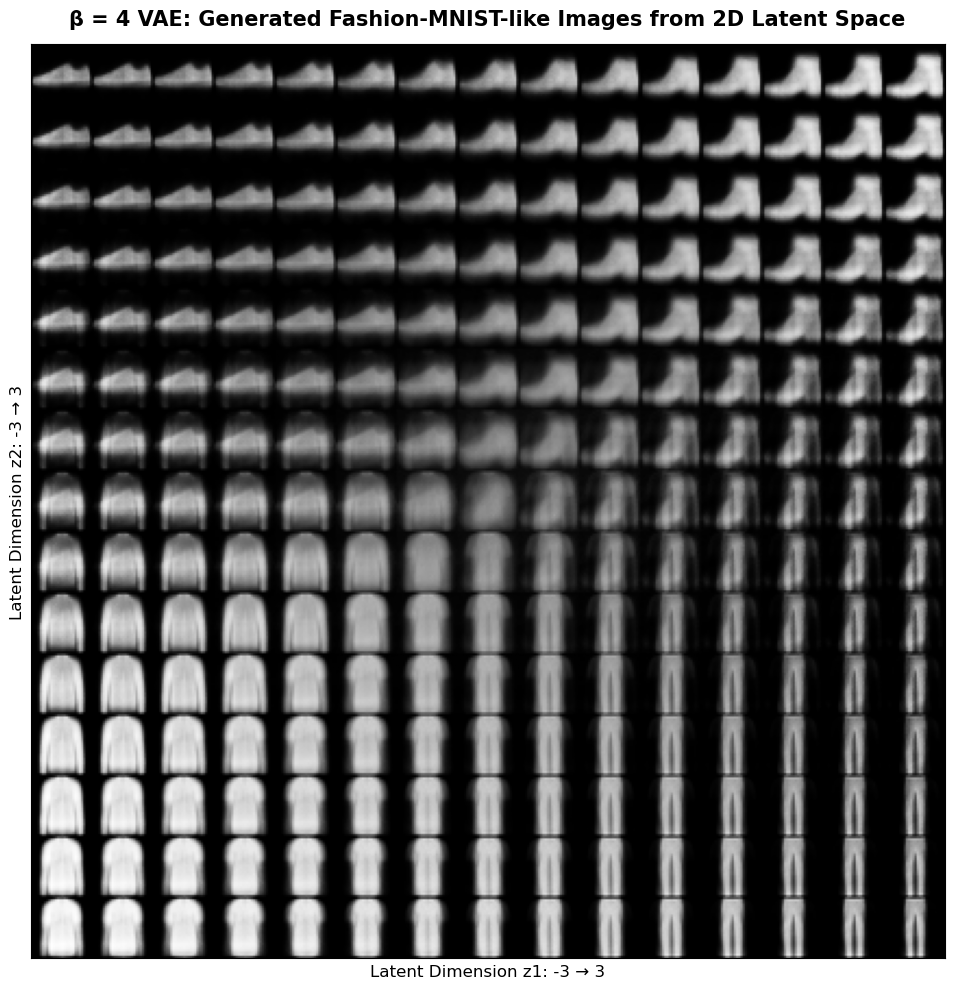

In [24]:
# ============================================================
# Step 23: Generate images from the beta = 4 latent space
# ============================================================

# Create a 2D grid of latent points.
# Source:
#   We manually create z1 and z2 coordinates from -3 to 3.
# Logic:
#   Each coordinate pair becomes one input point for the decoder.
grid_size = 15
z_range = np.linspace(-3, 3, grid_size)

# Empty image canvas to hold all generated images
generated_grid = np.zeros((28 * grid_size, 28 * grid_size))

# Loop through z2 and z1 values to generate one image per latent point
for row_idx, z2 in enumerate(z_range):
    for col_idx, z1 in enumerate(z_range):
        
        # Source:
        #   z1 and z2 come from the manually created latent grid.
        # Flow:
        #   [z1, z2] → decoder_beta_4 → generated flattened image
        z_point = np.array([[z1, z2]])

        generated_image_flat = decoder_beta_4.predict(
            z_point,
            verbose=0
        )

        # Convert generated image from 784 values back to 28 × 28 pixels
        generated_image = generated_image_flat.reshape(28, 28)

        # Place generated image into the large grid canvas
        row_start = row_idx * 28
        row_end = row_start + 28
        col_start = col_idx * 28
        col_end = col_start + 28

        generated_grid[row_start:row_end, col_start:col_end] = generated_image


# Plot generated image grid
plt.figure(figsize=(10, 10))

plt.imshow(generated_grid, cmap="gray")
plt.title(
    "β = 4 VAE: Generated Fashion-MNIST-like Images from 2D Latent Space",
    fontsize=15,
    fontweight="bold",
    pad=14
)

plt.xlabel("Latent Dimension z1: -3 → 3", fontsize=12)
plt.ylabel("Latent Dimension z2: -3 → 3", fontsize=12)

plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()

### Latent-Space Generation — Conclusion

The β = 4 VAE successfully generated Fashion-MNIST-like images from manually sampled 2D latent points.

The decoder received coordinate pairs from the range:

`[-3, 3] × [-3, 3]`

and converted each coordinate pair into a generated image.

The generated grid shows smooth transitions between different visual structures. This confirms that the VAE learned a continuous latent space rather than only memorising individual images.

At the edges of the latent space, the generated images become more extreme or less detailed. This is expected because those points are farther from the dense central region of the training distribution.

Overall, this confirms the generative ability of the VAE.

## Expert VAE Notebook — Final Conclusion

In this notebook, we built a **Variational Autoencoder (VAE)** on Fashion-MNIST.

Unlike a normal autoencoder, the VAE did not compress each image into one fixed bottleneck code. Instead, the encoder learned a probability-based latent representation using:

- **`z_mean`**: centre of the latent distribution
- **`z_log_var`**: spread of the latent distribution
- **`z`**: sampled latent point created with the reparameterisation trick

The reparameterisation trick was implemented as:

`z = μ + σ × ε`

### What was done

- Loaded and inspected Fashion-MNIST images
- Normalised pixel values from **0–255** to **0–1**
- Flattened each image from **28 × 28** into **784 values**
- Built a VAE encoder that outputs **`z_mean`**, **`z_log_var`**, and **`z`**
- Built a decoder that reconstructs images from 2D latent points
- Created a custom VAE training class with:
  - reconstruction loss
  - KL divergence
  - β-weighted total loss
- Trained a **β = 1 VAE**
- Trained a **β = 4 VAE**
- Compared reconstruction quality and KL loss
- Visualised both 2D latent spaces
- Generated new Fashion-MNIST-like images from the range `[-3, 3] × [-3, 3]`

### Key findings

The **β = 1 VAE** achieved better reconstruction quality:

`Average reconstruction MSE = 0.039027`

The **β = 4 VAE** achieved stronger latent-space regularisation:

`Final KL loss = 3.894046`

This confirms the expected β-VAE trade-off:

- **β = 1** preserves more image detail.
- **β = 4** creates a more regularised latent space but produces blurrier reconstructions.

### Final takeaway

The VAE successfully learned a smooth 2D latent space and used that space to generate new Fashion-MNIST-like images.

This shows why VAEs are generative models: they can reconstruct existing images and also create new images by decoding sampled latent points.